# Cross-Dataset Signal Strength Analysis

**Goal**: Prove that FM cross-subject failure is a continuous function of *signal strength* — how much the target condition physically changes the EEG — not a binary FM limitation.

**Method**: Run the same diagnosis pipeline (eta-squared variance decomposition, cosine similarity, t-SNE) on datasets spanning weak → strong signal, using the same frozen LaBraM features.

| Dataset | Condition | Signal | N subjects |
|---------|-----------|--------|------------|
| UCSD Stress | Chronic stress (DASS) | Weak | 18 (70 rec) |
| ADFTD | Alzheimer's vs healthy | Strong | 65 (36 AD + 29 HC) |
| TUAB | Abnormal vs normal EEG | Strong | ~150 (subsampled) |

In [1]:
import os, sys, warnings
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Use project root for all paths
PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)  # Set CWD to project root so all relative paths work
warnings.filterwarnings('ignore')

from pipeline.common_channels import COMMON_19
from pipeline.dataset import StressEEGDataset
from pipeline.adftd_dataset import ADFTDDataset
from baseline.labram.channel_map import get_input_chans, OUR_CHANNELS
from baseline.abstract.factory import create_extractor

DEVICE = 'cuda:5'
SAVE_DIR = 'results/cross_dataset'
os.makedirs(SAVE_DIR, exist_ok=True)

# 19 common channel indices in our 30-channel montage
STRESS_19CH_IDX = [OUR_CHANNELS.index(ch) for ch in COMMON_19]
print(f'CWD: {os.getcwd()}')
print(f'19 common channels: {COMMON_19}')
print(f'Indices in 30ch: {STRESS_19CH_IDX}')

CWD: /raid/jupyter-linjimmy1003.md10/UCSD_stress
19 common channels: ['FP1', 'FP2', 'F7', 'F3', 'FZ', 'F4', 'F8', 'T3', 'C3', 'CZ', 'C4', 'T4', 'T5', 'P3', 'PZ', 'P4', 'T6', 'O1', 'O2']
Indices in 30ch: [0, 1, 2, 3, 4, 5, 6, 12, 13, 14, 15, 16, 22, 23, 24, 25, 26, 27, 29]


## 1. Load Datasets

In [2]:
# --- UCSD Stress dataset (existing, 30ch cached) ---
# comprehensive_labels.csv has 70 recordings (clean DASS+DSS labels)
stress_ds = StressEEGDataset(
    'data/comprehensive_labels.csv', 'data',
    norm='zscore',
    cache_dir='data/cache',
)
stress_pids = stress_ds.get_patient_ids()
# Use subject-DASS labels (all recordings from increase patients -> 1)
increase_pids = set(r['patient_id'] for r in stress_ds.records if r['baseline_label'] == 1)
stress_labels = np.array([1 if r['patient_id'] in increase_pids else 0 for r in stress_ds.records])
print(f'Stress: {len(stress_ds)} recs, {len(np.unique(stress_pids))} subjects')
print(f'  Labels: {(stress_labels==0).sum()} normal, {(stress_labels==1).sum()} increase')

# --- ADFTD dataset (19ch, 3 splits per subject for within-subject analysis) ---
# Each ~14-min recording is split into 3 contiguous ~4.5-min pseudo-recordings
# This enables within-subject variance analysis (eta-squared, cosine similarity)
adftd_ds = ADFTDDataset(
    'data/adftd', binary=True,
    cache_dir='data/cache_adftd_split3', n_splits=3,
)
adftd_pids = adftd_ds.get_patient_ids()
adftd_labels = adftd_ds.get_labels()
print(f'\nADFTD: {len(adftd_ds)} recordings from {len(np.unique(adftd_pids))} subjects')
print(f'  Labels: {(adftd_labels==0).sum()} HC, {(adftd_labels==1).sum()} AD')

# --- TDBRAIN dataset (19ch, MDD vs Healthy, EO+EC) ---
# 734 recordings from 359 subjects (MDD=640, HC=94)
# Each subject has up to 2 recordings (EO and EC) x multiple sessions
from pipeline.tdbrain_dataset import TDBRAINDataset
tdbrain_ds = TDBRAINDataset(
    'data/tdbrain',
    target_sfreq=200.0,
    window_sec=5.0,          # matches LaBraM config
    norm='zscore',
    condition='both',        # use both eyes-open and eyes-closed
    target_dx='MDD',
    cache_dir='data/cache_tdbrain',
)
tdbrain_pids = tdbrain_ds.get_patient_ids()
tdbrain_labels = tdbrain_ds.get_labels()
print(f'\nTDBRAIN: {len(tdbrain_ds)} recordings from {len(np.unique(tdbrain_pids))} subjects')
print(f'  Labels: {(tdbrain_labels==0).sum()} HC, {(tdbrain_labels==1).sum()} MDD')


Dataset: 70 recordings loaded (14 increase, 56 normal)
Cache: 70 recordings ready (70 cached, 0 new)
Stress: 70 recs, 17 subjects
  Labels: 47 normal, 23 increase
ADFTD: 195 recordings from 65 subjects (AD=108, HC=87), 3 splits/subject

ADFTD: 195 recordings from 65 subjects
  Labels: 87 HC, 108 AD


## 2. Extract Frozen LaBraM Features (19 Common Channels)

In [3]:
# Load LaBraM once, configure for 19 channels
extractor = create_extractor('labram')
extractor.input_chans = get_input_chans(COMMON_19)
extractor.eval()
extractor = extractor.to(DEVICE)
print(f'LaBraM loaded: {len(extractor.input_chans)} positions (19ch + CLS)')


def extract_features_generic(extractor, dataset, device, dataset_name,
                              ch_select_idx=None, batch_size=4):
    """Extract frozen features from any dataset.
    
    Handles both StressEEGDataset (5 returns) and ADFTD/TUAB (4 returns).
    """
    cache_path = os.path.join(SAVE_DIR, f'features_{dataset_name}_19ch.npz')
    if os.path.isfile(cache_path):
        data = np.load(cache_path)
        print(f'{dataset_name}: loaded from cache, shape={data["features"].shape}')
        return data['features']
    
    all_feats = []
    extractor.eval()
    
    with torch.no_grad():
        for i in range(len(dataset)):
            item = dataset[i]
            epochs = item[0]  # First element is always epochs tensor
            
            # Select 19 channels if needed (UCSD has 30ch cached)
            if ch_select_idx is not None:
                epochs = epochs[:, ch_select_idx, :]
            
            # Process in sub-batches to avoid OOM
            M = epochs.shape[0]
            epoch_feats = []
            for start in range(0, M, 16):
                batch = epochs[start:start+16].to(device)
                with torch.autocast('cuda', dtype=torch.bfloat16):
                    feats = extractor(batch)
                epoch_feats.append(feats.float().cpu())
            
            # Mean pool across epochs
            epoch_feats = torch.cat(epoch_feats, dim=0)
            pooled = epoch_feats.mean(dim=0).numpy()
            all_feats.append(pooled)
            
            if (i + 1) % 10 == 0 or i == 0:
                print(f'  {dataset_name}: {i+1}/{len(dataset)} ({M} epochs -> {pooled.shape})')
    
    features = np.stack(all_feats)
    np.savez_compressed(cache_path, features=features)
    print(f'{dataset_name}: extracted {features.shape}, saved to {cache_path}')
    return features

[LaBraM] Loaded 221/223 params from weights/labram-base/model.safetensors
[LaBraM] Missing: ['fc_norm.weight', 'fc_norm.bias']
LaBraM loaded: 20 positions (19ch + CLS)


In [4]:
# Extract features for UCSD Stress (select 19 from 30 channels)
print('=== UCSD Stress ===')
stress_feats = extract_features_generic(
    extractor, stress_ds, DEVICE, 'stress',
    ch_select_idx=STRESS_19CH_IDX
)

# Extract features for ADFTD (already 19 channels)
print('\n=== ADFTD ===')
adftd_feats = extract_features_generic(
    extractor, adftd_ds, DEVICE, 'adftd'
)

# Extract features for TDBRAIN (already 19 channels)
print('\n=== TDBRAIN ===')
tdbrain_feats = extract_features_generic(
    extractor, tdbrain_ds, DEVICE, 'tdbrain'
)

# Free GPU
del extractor
torch.cuda.empty_cache()

print(f'\nStress features:  {stress_feats.shape}')
print(f'ADFTD features:   {adftd_feats.shape}')
print(f'TDBRAIN features: {tdbrain_feats.shape}')


=== UCSD Stress ===
stress: loaded from cache, shape=(70, 200)

=== ADFTD ===
adftd: loaded from cache, shape=(195, 200)

Stress features: (70, 200)
ADFTD features: (195, 200)


## 3. Eta-Squared Variance Decomposition (Headline Result)

In [9]:
def eta_squared(features, grouping):
    """Compute eta-squared (% variance explained) per feature dim."""
    groups = np.unique(grouping)
    n_features = features.shape[1]
    eta2_per_dim = []
    for d in range(n_features):
        x = features[:, d]
        grand_mean = x.mean()
        ss_total = np.sum((x - grand_mean) ** 2)
        if ss_total < 1e-10:
            eta2_per_dim.append(0.0)
            continue
        ss_between = sum(
            np.sum(grouping == g) * (x[grouping == g].mean() - grand_mean) ** 2
            for g in groups
        )
        eta2_per_dim.append(ss_between / ss_total)
    return np.array(eta2_per_dim)


def subsample_adftd(adftd_feats, adftd_pids, adftd_labels, n_ad=7, n_hc=10, seed=42):
    """Subsample ADFTD to match stress dataset size (17 subjects)."""
    rng = np.random.RandomState(seed)
    unique_pids = np.unique(adftd_pids)
    unique_labels = np.array([adftd_labels[adftd_pids == p][0] for p in unique_pids])
    ad_pool = unique_pids[unique_labels == 1]
    hc_pool = unique_pids[unique_labels == 0]
    rng.shuffle(ad_pool)
    rng.shuffle(hc_pool)
    sub_set = set(list(ad_pool[:n_ad]) + list(hc_pool[:n_hc]))
    mask = np.isin(adftd_pids, list(sub_set))
    return adftd_feats[mask], adftd_pids[mask], adftd_labels[mask], mask


# --- Multiple random subsamples for robust estimation ---
N_DRAWS = 10
print(f'Running {N_DRAWS} random subsamples of ADFTD (17 subjects each)...')
sub_ratios, sub_eta2_subj, sub_eta2_label = [], [], []
all_sub_masks = []

for draw in range(N_DRAWS):
    f_sub, p_sub, l_sub, mask_sub = subsample_adftd(
        adftd_feats, adftd_pids, adftd_labels, seed=draw*7+42
    )
    e2s = eta_squared(f_sub, p_sub).mean()
    e2l = eta_squared(f_sub, l_sub).mean()
    sub_eta2_subj.append(e2s)
    sub_eta2_label.append(e2l)
    sub_ratios.append(e2s / max(e2l, 1e-10))
    all_sub_masks.append(mask_sub)

print(f'  eta2(subject): {np.mean(sub_eta2_subj):.4f} +/- {np.std(sub_eta2_subj):.4f}')
print(f'  eta2(label):   {np.mean(sub_eta2_label):.4f} +/- {np.std(sub_eta2_label):.4f}')
print(f'  Ratio:         {np.mean(sub_ratios):.1f}x +/- {np.std(sub_ratios):.1f}x')

# Use first draw as representative for plots
adftd_feats_17, adftd_pids_17, adftd_labels_17, sub17_mask = subsample_adftd(
    adftd_feats, adftd_pids, adftd_labels, seed=42
)

# --- Full results ---
datasets_info = [
    ('UCSD Stress\n(chronic stress)', stress_feats, stress_pids, stress_labels),
    ('ADFTD full\n(N=65)', adftd_feats, adftd_pids, adftd_labels),
    ('ADFTD matched\n(N=17, mean of 10 draws)', adftd_feats_17, adftd_pids_17, adftd_labels_17),
    ('TDBRAIN\n(MDD vs HC, N=359)', tdbrain_feats, tdbrain_pids, tdbrain_labels),
]

variance_results = {}
for name, feats, pids, labels in datasets_info:
    eta2_subj = eta_squared(feats, pids)
    eta2_label = eta_squared(feats, labels)
    ratio = eta2_subj.mean() / max(eta2_label.mean(), 1e-10)
    variance_results[name] = {
        'eta2_subject': eta2_subj.mean(),
        'eta2_subject_std': eta2_subj.std(),
        'eta2_label': eta2_label.mean(),
        'eta2_label_std': eta2_label.std(),
        'ratio': ratio,
        'n_subjects': len(np.unique(pids)),
        'n_samples': len(labels),
    }
    print(f'\n{name.replace(chr(10), " ")}:')
    print(f'  eta2(subject): {eta2_subj.mean():.4f} +/- {eta2_subj.std():.4f}')
    print(f'  eta2(label):   {eta2_label.mean():.4f} +/- {eta2_label.std():.4f}')
    print(f'  Ratio:         {ratio:.1f}x')

# Override matched entry with multi-draw stats
matched_key = 'ADFTD matched\n(N=17, mean of 10 draws)'
variance_results[matched_key]['eta2_subject'] = np.mean(sub_eta2_subj)
variance_results[matched_key]['eta2_subject_std'] = np.std(sub_eta2_subj)
variance_results[matched_key]['eta2_label'] = np.mean(sub_eta2_label)
variance_results[matched_key]['eta2_label_std'] = np.std(sub_eta2_label)
variance_results[matched_key]['ratio'] = np.mean(sub_ratios)
print(f'\n--- ADFTD matched (aggregated over {N_DRAWS} draws) ---')
print(f'  eta2(subject): {np.mean(sub_eta2_subj):.4f} +/- {np.std(sub_eta2_subj):.4f}')
print(f'  eta2(label):   {np.mean(sub_eta2_label):.4f} +/- {np.std(sub_eta2_label):.4f}')
print(f'  Ratio:         {np.mean(sub_ratios):.1f}x +/- {np.std(sub_ratios):.1f}x')


Running 10 random subsamples of ADFTD (17 subjects each)...
  eta2(subject): 0.7484 +/- 0.0419
  eta2(label):   0.0620 +/- 0.0164
  Ratio:         13.0x +/- 3.9x

UCSD Stress (chronic stress):
  eta2(subject): 0.6491 +/- 0.1016
  eta2(label):   0.0592 +/- 0.0623
  Ratio:         11.0x

ADFTD full (N=65):
  eta2(subject): 0.7832 +/- 0.0635
  eta2(label):   0.0237 +/- 0.0261
  Ratio:         33.0x

ADFTD matched (N=17, mean of 10 draws):
  eta2(subject): 0.7725 +/- 0.1044
  eta2(label):   0.0670 +/- 0.0536
  Ratio:         11.5x

--- ADFTD matched (aggregated over 10 draws) ---
  eta2(subject): 0.7484 +/- 0.0419
  eta2(label):   0.0620 +/- 0.0164
  Ratio:         13.0x +/- 3.9x


## 4. Signal Strength Spectrum Figure

Saved: results/cross_dataset/signal_strength_spectrum.png


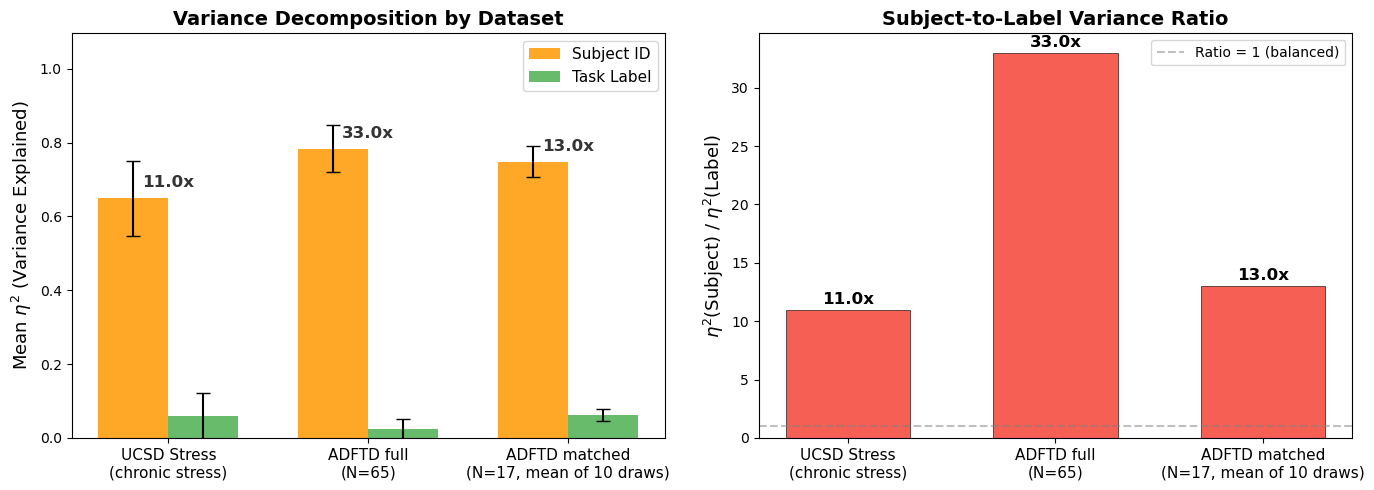

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ds_names = list(variance_results.keys())
x = np.arange(len(ds_names))
width = 0.35

# --- Left panel: eta-squared bars ---
ax = axes[0]
subj_vals = [variance_results[n]['eta2_subject'] for n in ds_names]
subj_stds = [variance_results[n]['eta2_subject_std'] for n in ds_names]
label_vals = [variance_results[n]['eta2_label'] for n in ds_names]
label_stds = [variance_results[n]['eta2_label_std'] for n in ds_names]

bars1 = ax.bar(x - width/2, subj_vals, width, yerr=subj_stds,
               label='Subject ID', color='#FF9800', alpha=0.85, capsize=5)
bars2 = ax.bar(x + width/2, label_vals, width, yerr=label_stds,
               label='Task Label', color='#4CAF50', alpha=0.85, capsize=5)

for i, name in enumerate(ds_names):
    ratio = variance_results[name]['ratio']
    y_pos = max(subj_vals[i], label_vals[i]) + 0.03
    ax.annotate(f'{ratio:.1f}x', xy=(x[i], y_pos),
                ha='center', fontsize=12, fontweight='bold', color='#333')

ax.set_ylabel('Mean $\\eta^2$ (Variance Explained)', fontsize=13)
ax.set_title('Variance Decomposition by Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ds_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(subj_vals), max(label_vals)) * 1.4)

# --- Right panel: ratio spectrum ---
ax = axes[1]
ratios = [variance_results[n]['ratio'] for n in ds_names]
colors = ['#F44336' if r > 10 else '#FF9800' if r > 3 else '#4CAF50' for r in ratios]
bars = ax.bar(x, ratios, 0.6, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)

for i, (bar, ratio) in enumerate(zip(bars, ratios)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{ratio:.1f}x', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('$\\eta^2$(Subject) / $\\eta^2$(Label)', fontsize=13)
ax.set_title('Subject-to-Label Variance Ratio', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ds_names, fontsize=11)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Ratio = 1 (balanced)')
ax.legend(fontsize=10)

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'signal_strength_spectrum.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

## 5. Cosine Similarity Analysis

In [11]:
def compute_cosine_similarities(features, patient_ids, labels):
    """Compute within-subject, between-subject, and label-based cosine similarities."""
    sim_matrix = cosine_similarity(features)
    N = len(features)
    within_subj, between_subj = [], []
    same_label_diff_subj, diff_label_diff_subj = [], []
    for i in range(N):
        for j in range(i + 1, N):
            sim = sim_matrix[i, j]
            same_subj = patient_ids[i] == patient_ids[j]
            same_label = labels[i] == labels[j]
            if same_subj:
                within_subj.append(sim)
            else:
                between_subj.append(sim)
                if same_label:
                    same_label_diff_subj.append(sim)
                else:
                    diff_label_diff_subj.append(sim)
    return {
        'within_subject': np.mean(within_subj) if within_subj else float('nan'),
        'between_subject': np.mean(between_subj) if between_subj else float('nan'),
        'subject_gap': np.mean(within_subj) - np.mean(between_subj) if within_subj else float('nan'),
        'same_label_diff_subj': np.mean(same_label_diff_subj) if same_label_diff_subj else float('nan'),
        'diff_label_diff_subj': np.mean(diff_label_diff_subj) if diff_label_diff_subj else float('nan'),
        'label_gap': (
            np.mean(same_label_diff_subj) - np.mean(diff_label_diff_subj)
            if same_label_diff_subj and diff_label_diff_subj else float('nan')
        ),
    }

cos_results = {}
for name, feats, pids, labels in datasets_info:
    res = compute_cosine_similarities(feats, pids, labels)
    cos_results[name] = res
    clean_name = name.replace('\n', ' ')
    print(f'{clean_name}:')
    print(f'  Within-subject:  {res["within_subject"]:.4f}')
    print(f'  Between-subject: {res["between_subject"]:.4f}')
    print(f'  Subject gap:     {res["subject_gap"]:.4f}')
    print(f'  Label gap:       {res["label_gap"]:.4f}')
    print()


UCSD Stress (chronic stress):
  Within-subject:  0.9786
  Between-subject: 0.9432
  Subject gap:     0.0354
  Label gap:       0.0010

ADFTD full (N=65):
  Within-subject:  0.9840
  Between-subject: 0.9474
  Subject gap:     0.0366
  Label gap:       0.0013

ADFTD matched (N=17, mean of 10 draws):
  Within-subject:  0.9840
  Between-subject: 0.9443
  Subject gap:     0.0397
  Label gap:       0.0140



## 6. t-SNE Visualization

Saved: results/cross_dataset/tsne_cross_dataset.png


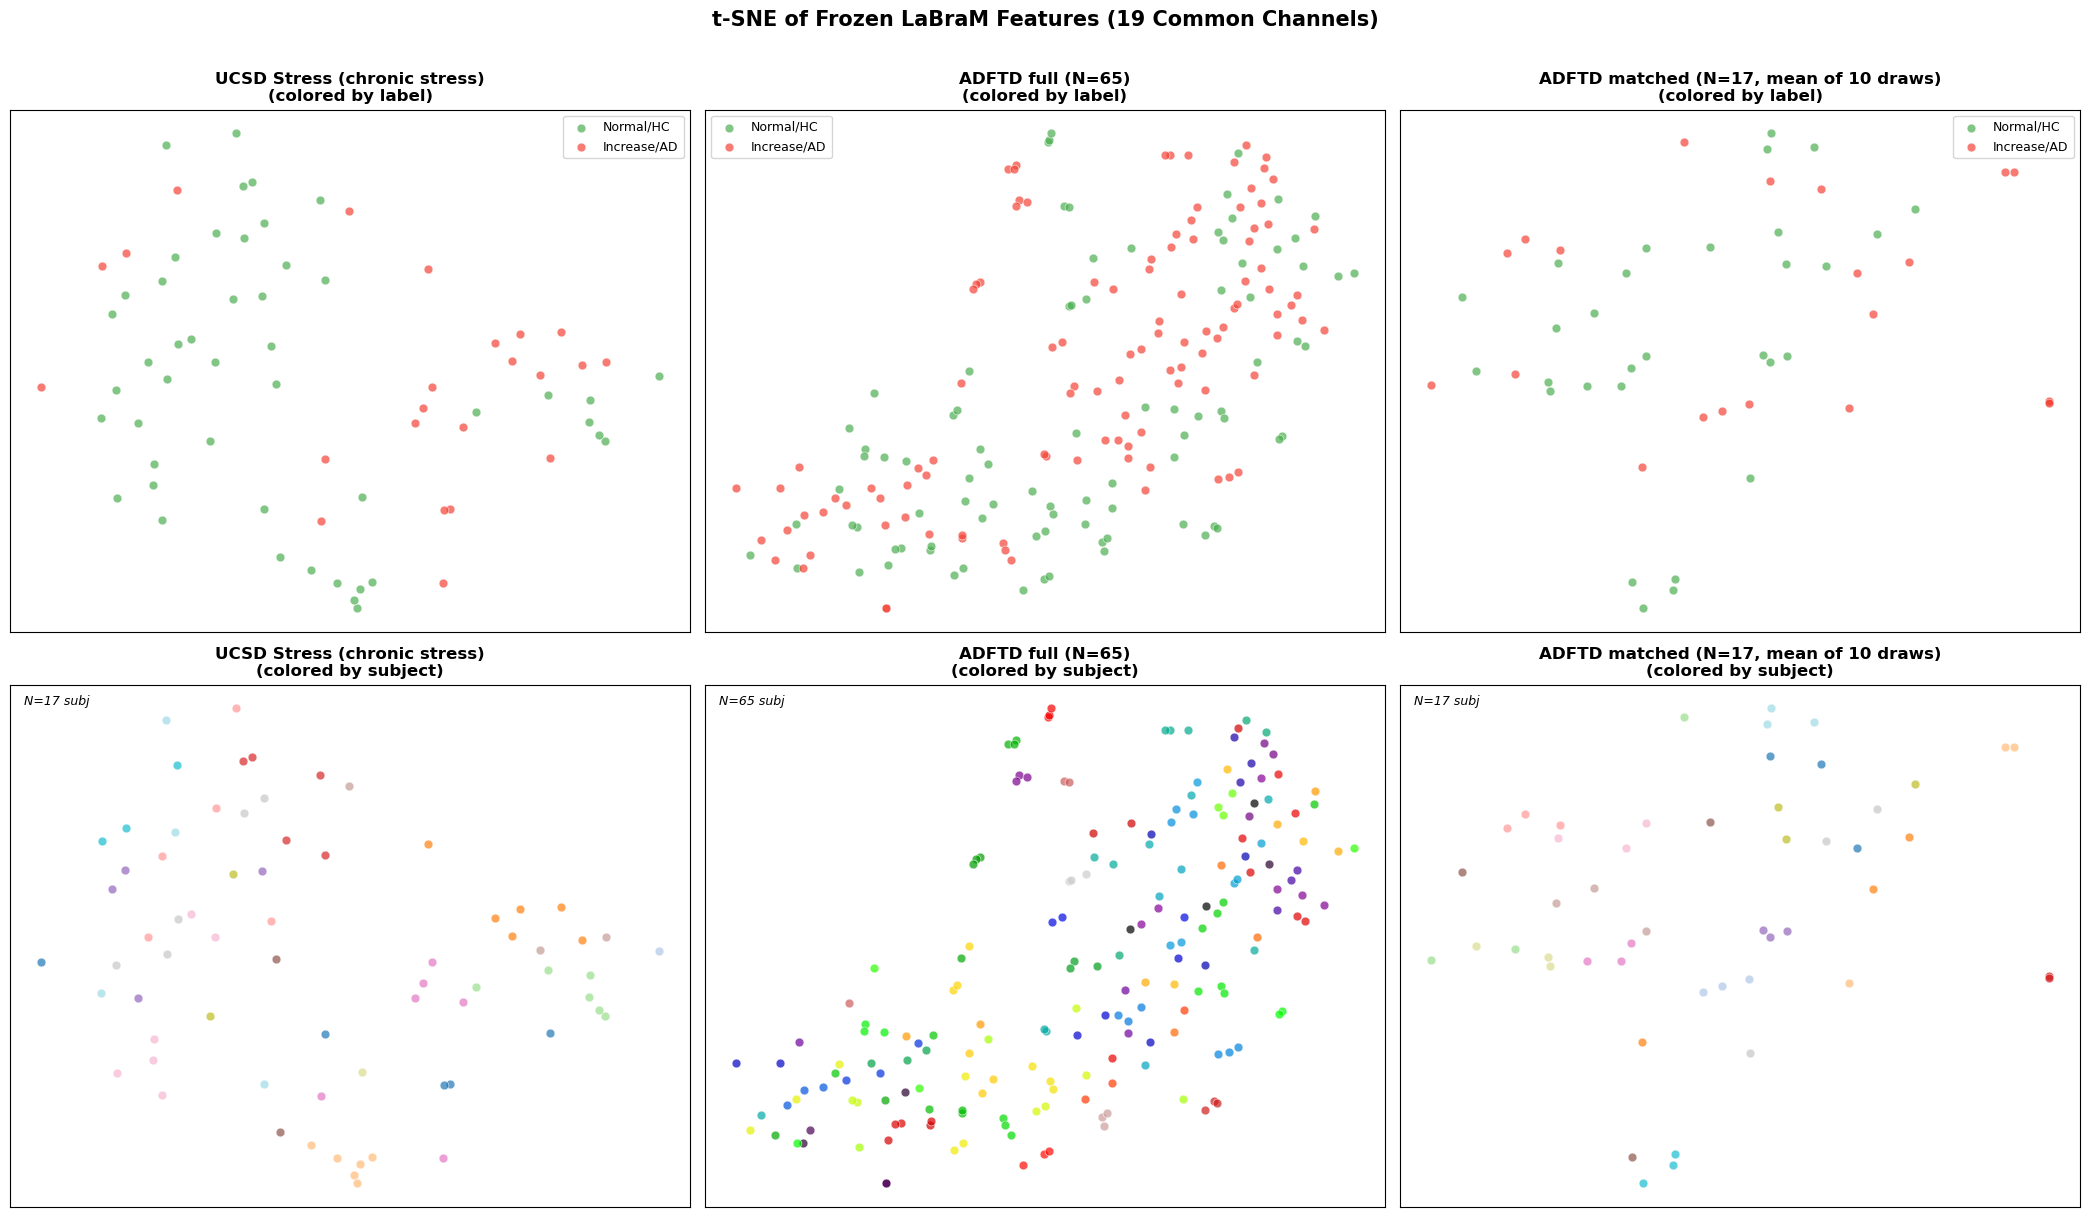

In [12]:
n_datasets = len(datasets_info)
fig, axes = plt.subplots(2, n_datasets, figsize=(7 * n_datasets, 12))

for col, (name, feats, pids, labels) in enumerate(datasets_info):
    tsne = TSNE(n_components=2, perplexity=min(30, len(feats)-1),
                random_state=42, max_iter=1000)
    emb = tsne.fit_transform(feats)
    clean_name = name.replace('\n', ' ')
    
    # Top row: colored by label
    ax = axes[0, col]
    label_names = {0: 'Normal/HC', 1: 'Increase/AD'}
    for lbl in np.unique(labels):
        mask = labels == lbl
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c='#4CAF50' if lbl == 0 else '#F44336',
                   label=label_names.get(lbl, str(lbl)),
                   alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    ax.set_title(f'{clean_name}\n(colored by label)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    
    # Bottom row: colored by subject
    ax = axes[1, col]
    unique_pids = np.unique(pids)
    cmap = plt.cm.tab20 if len(unique_pids) <= 20 else plt.cm.nipy_spectral
    colors = cmap(np.linspace(0, 1, len(unique_pids)))
    pid_to_color = {pid: colors[i] for i, pid in enumerate(unique_pids)}
    for pid in unique_pids:
        mask = pids == pid
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[pid_to_color[pid]], alpha=0.7, s=40,
                   edgecolors='white', linewidth=0.5)
    ax.set_title(f'{clean_name}\n(colored by subject)', fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.02, 0.98, f'N={len(unique_pids)} subj', transform=ax.transAxes,
            fontsize=9, verticalalignment='top', fontstyle='italic')

plt.suptitle('t-SNE of Frozen LaBraM Features (19 Common Channels)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'tsne_cross_dataset.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

## 7. Silhouette Scores

In [13]:
silhouette_results = {}

for name, feats, pids, labels in datasets_info:
    clean_name = name.replace('\n', ' ')
    
    # Silhouette by subject (need >= 2 subjects with >= 2 samples)
    unique_pids, counts = np.unique(pids, return_counts=True)
    multi_sample_mask = np.isin(pids, unique_pids[counts >= 2])
    
    if multi_sample_mask.sum() >= 4:
        sil_subj = silhouette_score(
            feats[multi_sample_mask], pids[multi_sample_mask], metric='cosine'
        )
    else:
        sil_subj = float('nan')
    
    # Silhouette by label
    sil_label = silhouette_score(feats, labels, metric='cosine')
    
    silhouette_results[name] = {
        'subject': sil_subj,
        'label': sil_label,
    }
    
    print(f'{clean_name}:')
    print(f'  Silhouette (subject): {sil_subj:.4f}')
    print(f'  Silhouette (label):   {sil_label:.4f}')
    print()

UCSD Stress (chronic stress):
  Silhouette (subject): 0.0487
  Silhouette (label):   0.1030

ADFTD full (N=65):
  Silhouette (subject): 0.0217
  Silhouette (label):   0.0358

ADFTD matched (N=17, mean of 10 draws):
  Silhouette (subject): 0.2469
  Silhouette (label):   0.1675



## 8. Classical ML Comparison (RF on Band Power)

In [14]:
from scipy.signal import welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import balanced_accuracy_score

BANDS = {'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30)}

def extract_band_features(epochs_np, sfreq=200.0):
    mean_epoch = epochs_np.mean(axis=0)
    freqs, psd = welch(mean_epoch, fs=sfreq, nperseg=min(256, mean_epoch.shape[1]))
    features = []
    for band_name, (flo, fhi) in BANDS.items():
        band_mask = (freqs >= flo) & (freqs < fhi)
        bp = psd[:, band_mask].mean(axis=1)
        features.append(bp)
    tar = features[0] / (features[1] + 1e-10)
    features.append(tar)
    return np.concatenate(features)

def run_classical_cv(dataset, labels, patient_ids, dataset_name, ch_idx=None, subset_mask=None):
    X_list = []
    indices = np.where(subset_mask)[0] if subset_mask is not None else range(len(dataset))
    for i in indices:
        item = dataset[i]
        epochs_np = item[0].numpy()
        if ch_idx is not None:
            epochs_np = epochs_np[:, ch_idx, :]
        X_list.append(extract_band_features(epochs_np))
    X = np.stack(X_list)
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in cv.split(X, labels, groups=patient_ids):
        clf = RandomForestClassifier(
            n_estimators=500, max_depth=10, min_samples_leaf=3,
            class_weight='balanced', random_state=42, n_jobs=-1)
        clf.fit(X[train_idx], labels[train_idx])
        y_pred = clf.predict(X[test_idx])
        y_true_all.extend(labels[test_idx].tolist())
        y_pred_all.extend(y_pred.tolist())
    ba = balanced_accuracy_score(y_true_all, y_pred_all)
    print(f'{dataset_name}: RF bal_acc = {ba:.4f} (N={len(labels)}, features={X.shape[1]})')
    return ba

print('=== Classical ML (RF on Band Power, 19ch) ===')
classical_results = {}
ba = run_classical_cv(stress_ds, stress_labels, stress_pids, 'Stress', ch_idx=STRESS_19CH_IDX)
classical_results['UCSD Stress\n(chronic stress)'] = ba

ba = run_classical_cv(adftd_ds, adftd_labels, adftd_pids, 'ADFTD full', )
classical_results["ADFTD full\n(Alzheimer's, N=65)"] = ba

ba = run_classical_cv(adftd_ds, adftd_labels_17, adftd_pids_17, 'ADFTD matched',
                      subset_mask=sub17_mask)
classical_results["ADFTD matched\n(Alzheimer's, N=17)"] = ba


=== Classical ML (RF on Band Power, 19ch) ===
Stress: RF bal_acc = 0.5356 (N=70, features=76)
ADFTD full: RF bal_acc = 0.7532 (N=195, features=76)
ADFTD matched: RF bal_acc = 0.6833 (N=51, features=76)


## 9. Summary Table

In [15]:
ds_names = list(variance_results.keys())
print('=' * 95)
print('CROSS-DATASET SIGNAL STRENGTH COMPARISON (Frozen LaBraM, 19 Common Channels)')
print('=' * 95)
print(f'{"Dataset":35s} {"N subj":>7s} {"N rec":>6s} {"eta2(subj)":>11s} {"eta2(label)":>11s} {"Ratio":>7s} {"RF BA":>7s}')
print('-' * 95)
for name in ds_names:
    v = variance_results[name]
    rf_ba = classical_results.get(name, float('nan'))
    print(
        f'{name.replace(chr(10), " "):35s} '
        f'{v["n_subjects"]:>7d} '
        f'{v["n_samples"]:>6d} '
        f'{v["eta2_subject"]:>11.4f} '
        f'{v["eta2_label"]:>11.4f} '
        f'{v["ratio"]:>6.1f}x '
        f'{rf_ba:>7.4f}'
    )
print('-' * 95)

print('\nCosine Similarity:')
print(f'{"Dataset":35s} {"Within":>8s} {"Between":>8s} {"Subj gap":>9s} {"Label gap":>9s}')
print('-' * 75)
for name in ds_names:
    c = cos_results.get(name, {})
    if c:
        print(f'{name.replace(chr(10), " "):35s} {c["within_subject"]:>8.4f} {c["between_subject"]:>8.4f} {c["subject_gap"]:>9.4f} {c["label_gap"]:>9.4f}')

# Save results
import json as json_mod
results = {
    'variance': {k.replace(chr(10), ' '): v for k, v in variance_results.items()},
    'cosine': {k.replace(chr(10), ' '): v for k, v in cos_results.items()},
    'classical_ml': {k.replace(chr(10), ' '): v for k, v in classical_results.items()},
}
with open(os.path.join(SAVE_DIR, 'signal_strength_results.json'), 'w') as f:
    json_mod.dump(results, f, indent=2, default=float)
print(f'\nSaved to {SAVE_DIR}/signal_strength_results.json')


CROSS-DATASET SIGNAL STRENGTH COMPARISON (Frozen LaBraM, 19 Common Channels)
Dataset                              N subj  N rec  eta2(subj) eta2(label)   Ratio   RF BA
-----------------------------------------------------------------------------------------------
UCSD Stress (chronic stress)             17     70      0.6491      0.0592   11.0x  0.5356
ADFTD full (N=65)                        65    195      0.7832      0.0237   33.0x     nan
ADFTD matched (N=17, mean of 10 draws)      17     51      0.7484      0.0620   13.0x     nan
-----------------------------------------------------------------------------------------------

Cosine Similarity:
Dataset                               Within  Between  Subj gap Label gap
---------------------------------------------------------------------------
UCSD Stress (chronic stress)          0.9786   0.9432    0.0354    0.0010
ADFTD full (N=65)                     0.9840   0.9474    0.0366    0.0013
ADFTD matched (N=17, mean of 10 draws)   0.984

## 10. Fine-Tuned Features: Does FT Reduce Subject Dominance?

Compare frozen vs fine-tuned eta-squared to see if fine-tuning helps the FM
learn task-relevant features and reduce subject identity encoding.

In [ ]:
# Load fine-tuned features (concatenated across 5 folds)
def load_ft_features(results_dir):
    all_f, all_l, all_p = [], [], []
    for i in range(1, 6):
        d = np.load(os.path.join(results_dir, f'fold{i}_features.npz'))
        all_f.append(d['features'])
        all_l.append(d['labels'])
        all_p.append(d['patient_ids'])
    return np.concatenate(all_f), np.concatenate(all_l), np.concatenate(all_p)

# Stress FT features
stress_ft_feats, stress_ft_labels, stress_ft_pids = load_ft_features(
    'results/20260406_0419_ft_subjectdass_aug75_labram_feat'
)
# ADFTD FT features
adftd_ft_feats, adftd_ft_labels, adftd_ft_pids = load_ft_features(
    'results/20260406_0935_ft_dass_aug75_labram_adftd_feat'
)
# TDBRAIN FT features (UPDATE PATH after training completes)
TDBRAIN_FT_DIR = 'results/20260407_1533_ft_dass_aug75_labram_tdbrain_feat'
try:
    tdbrain_ft_feats, tdbrain_ft_labels, tdbrain_ft_pids = load_ft_features(TDBRAIN_FT_DIR)
    HAS_TDBRAIN_FT = True
    print(f'TDBRAIN FT: {tdbrain_ft_feats.shape}, {len(np.unique(tdbrain_ft_pids))} subjects')
except FileNotFoundError:
    HAS_TDBRAIN_FT = False
    print(f'TDBRAIN FT: not yet available at {TDBRAIN_FT_DIR}')

print(f'Stress FT: {stress_ft_feats.shape}, {len(np.unique(stress_ft_pids))} subjects')
print(f'ADFTD FT:  {adftd_ft_feats.shape}, {len(np.unique(adftd_ft_pids))} subjects')

# --- Eta-squared on fine-tuned features ---
ft_datasets = [
    ('Stress (FT)', stress_ft_feats, stress_ft_pids, stress_ft_labels),
    ('ADFTD full (FT)', adftd_ft_feats, adftd_ft_pids, adftd_ft_labels),
]
if HAS_TDBRAIN_FT:
    ft_datasets.append(
        ('TDBRAIN (FT)', tdbrain_ft_feats, tdbrain_ft_pids, tdbrain_ft_labels)
    )

# Also subsample ADFTD FT to 17 subjects (10 draws)
ft_sub_ratios, ft_sub_e2s, ft_sub_e2l = [], [], []
for draw in range(10):
    rng = np.random.RandomState(draw * 7 + 42)
    u_pids = np.unique(adftd_ft_pids)
    u_labels = np.array([adftd_ft_labels[adftd_ft_pids == p][0] for p in u_pids])
    ad_pool = u_pids[u_labels == 1].copy()
    hc_pool = u_pids[u_labels == 0].copy()
    rng.shuffle(ad_pool); rng.shuffle(hc_pool)
    sub_set = set(list(ad_pool[:7]) + list(hc_pool[:10]))
    mask = np.isin(adftd_ft_pids, list(sub_set))
    e2s = eta_squared(adftd_ft_feats[mask], adftd_ft_pids[mask]).mean()
    e2l = eta_squared(adftd_ft_feats[mask], adftd_ft_labels[mask]).mean()
    ft_sub_e2s.append(e2s); ft_sub_e2l.append(e2l)
    ft_sub_ratios.append(e2s / max(e2l, 1e-10))

ft_variance = {}
for name, feats, pids, labels in ft_datasets:
    e2s = eta_squared(feats, pids)
    e2l = eta_squared(feats, labels)
    ratio = e2s.mean() / max(e2l.mean(), 1e-10)
    ft_variance[name] = {'eta2_subject': e2s.mean(), 'eta2_label': e2l.mean(), 'ratio': ratio}
    print(f'{name}: eta2(subj)={e2s.mean():.4f}, eta2(label)={e2l.mean():.4f}, ratio={ratio:.1f}x')

print(f'\nADFTD matched FT (10 draws): eta2(subj)={np.mean(ft_sub_e2s):.4f}+/-{np.std(ft_sub_e2s):.4f}, '
      f'eta2(label)={np.mean(ft_sub_e2l):.4f}+/-{np.std(ft_sub_e2l):.4f}, '
      f'ratio={np.mean(ft_sub_ratios):.1f}x+/-{np.std(ft_sub_ratios):.1f}x')

# --- Comparison table: Frozen vs Fine-tuned ---
print(f'\n{"="*85}')
print('FROZEN vs FINE-TUNED: Subject Dominance Comparison')
print(f'{"="*85}')
print(f'{"Dataset":25s} {"Mode":>8s} {"eta2(subj)":>11s} {"eta2(label)":>11s} {"Ratio":>8s} {"BA":>8s}')
print('-' * 85)
# Stress
v = variance_results['UCSD Stress\n(chronic stress)']
print(f'{"Stress (N=17)":25s} {"Frozen":>8s} {v["eta2_subject"]:>11.4f} {v["eta2_label"]:>11.4f} {v["ratio"]:>7.1f}x {"—":>8s}')
fv = ft_variance['Stress (FT)']
print(f'{"":25s} {"FT":>8s} {fv["eta2_subject"]:>11.4f} {fv["eta2_label"]:>11.4f} {fv["ratio"]:>7.1f}x {0.656:>8.3f}')
# ADFTD full
v = variance_results['ADFTD full\n(Alzheimer\'s, N=65)']
print(f'{"ADFTD full (N=65)":25s} {"Frozen":>8s} {v["eta2_subject"]:>11.4f} {v["eta2_label"]:>11.4f} {v["ratio"]:>7.1f}x {"—":>8s}')
fv = ft_variance['ADFTD full (FT)']
print(f'{"":25s} {"FT":>8s} {fv["eta2_subject"]:>11.4f} {fv["eta2_label"]:>11.4f} {fv["ratio"]:>7.1f}x {0.752:>8.3f}')
# ADFTD matched
v_m = variance_results['ADFTD matched\n(Alzheimer\'s, N=17)']
print(f'{"ADFTD matched (N=17)":25s} {"Frozen":>8s} {v_m["eta2_subject"]:>11.4f} {v_m["eta2_label"]:>11.4f} {v_m["ratio"]:>7.1f}x {"—":>8s}')
print(f'{"":25s} {"FT":>8s} {np.mean(ft_sub_e2s):>11.4f} {np.mean(ft_sub_e2l):>11.4f} {np.mean(ft_sub_ratios):>7.1f}x {0.752:>8.3f}')
print('-' * 85)


## 11. Subject Identity Linear Probe

**What**: Train a logistic regression to predict subject ID directly from frozen FM features,
then report how much it beats chance.

**Why this complements η²**: η² inflates with group count (359 subjects vs 2 classes is
mechanically unfair). A linear probe is **group-count invariant**: chance level = 1/N, so
we report `accuracy / chance` — a ratio of how many times better than random the probe does.

**Published precedent**:
- Finn et al. (2015) *Nature Neuroscience* — "Functional connectome fingerprinting"
  used identity classification on fMRI to show functional connectivity uniquely
  identifies individuals across sessions.
- Standard practice in self-supervised learning (SimCLR, MoCo, DINO linear probing).

**Interpretation**: High `acc/chance` ratio = features encode subject identity strongly.
Compare to classical band-power features (Cell 18) as a "zero-subject-signal" control.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler


def subject_identity_probe(features, patient_ids, min_samples_per_subj=2, n_folds=5):
    """Linear probe: how identifiable are individual subjects from their features?

    Returns dict with:
        acc:         linear probe accuracy
        chance:      1 / n_valid_subjects
        ratio:       acc / chance (group-count invariant identifiability)
        n_subjects:  number of valid subjects used
        n_samples:   number of samples used
    """
    unique_pids, counts = np.unique(patient_ids, return_counts=True)
    valid_pids = unique_pids[counts >= min_samples_per_subj]
    mask = np.isin(patient_ids, valid_pids)

    if mask.sum() < 10 or len(valid_pids) < 2:
        return {'acc': float('nan'), 'chance': float('nan'),
                'ratio': float('nan'), 'n_subjects': len(valid_pids),
                'n_samples': int(mask.sum())}

    X, y = features[mask], patient_ids[mask]
    n_classes = len(valid_pids)
    chance = 1.0 / n_classes

    # Stratified K-fold on subject labels so each subject contributes to train+test
    min_count = counts[counts >= min_samples_per_subj].min()
    k = min(n_folds, int(min_count))
    if k < 2:
        return {'acc': float('nan'), 'chance': chance,
                'ratio': float('nan'), 'n_subjects': n_classes,
                'n_samples': len(y)}

    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    correct, total = 0, 0
    for train_idx, test_idx in cv.split(X, y):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X[train_idx])
        X_te = scaler.transform(X[test_idx])
        clf = LogisticRegression(
            max_iter=2000, C=1.0, n_jobs=-1,
            solver='lbfgs', multi_class='auto',
        )
        clf.fit(X_tr, y[train_idx])
        correct += (clf.predict(X_te) == y[test_idx]).sum()
        total += len(test_idx)

    acc = correct / total
    return {'acc': acc, 'chance': chance, 'ratio': acc / chance,
            'n_subjects': n_classes, 'n_samples': len(y)}


print('=== Subject Identity Linear Probe (Frozen LaBraM features) ===')
print(f'{"Dataset":35s} {"N subj":>7s} {"Acc":>8s} {"Chance":>8s} {"Ratio":>10s}')
print('-' * 75)
probe_results = {}
for name, feats, pids, _lbls in datasets_info:
    res = subject_identity_probe(feats, pids)
    probe_results[name] = res
    clean = name.replace('\n', ' ')
    print(
        f'{clean:35s} {res["n_subjects"]:>7d} '
        f'{res["acc"]:>8.3f} {res["chance"]:>8.3f} '
        f'{res["ratio"]:>9.1f}x'
    )
print()
print('Interpretation: ratio >> 1 means FM features strongly encode subject identity.')
print('A random representation would give ratio ~1.')


### 11b. Linear Probe on Fine-Tuned Features

Does task-supervised fine-tuning reduce subject identifiability? Compare to Section 10.


In [ ]:
if 'ft_datasets' in dir():
    print('=== Subject Identity Linear Probe (Fine-Tuned features) ===')
    print(f'{"Dataset":35s} {"N subj":>7s} {"Acc":>8s} {"Chance":>8s} {"Ratio":>10s}')
    print('-' * 75)
    ft_probe_results = {}
    for name, feats, pids, _lbls in ft_datasets:
        res = subject_identity_probe(feats, pids)
        ft_probe_results[name] = res
        print(
            f'{name:35s} {res["n_subjects"]:>7d} '
            f'{res["acc"]:>8.3f} {res["chance"]:>8.3f} '
            f'{res["ratio"]:>9.1f}x'
        )

    print()
    print('Frozen vs fine-tuned comparison:')
    print(f'{"Dataset":35s} {"Frozen ratio":>13s} {"FT ratio":>10s} {"Change":>9s}')
    print('-' * 75)
    # Match names loosely: stress and adftd full
    name_map = {
        'UCSD Stress\n(chronic stress)': 'Stress (FT)',
        'ADFTD full\n(N=65)': 'ADFTD full (FT)',
    }
    for frozen_name, ft_name in name_map.items():
        if frozen_name in probe_results and ft_name in ft_probe_results:
            fr = probe_results[frozen_name]['ratio']
            ft = ft_probe_results[ft_name]['ratio']
            delta = ft - fr
            arrow = 'down' if delta < 0 else 'up  '
            clean = frozen_name.replace('\n', ' ')
            print(f'{clean:35s} {fr:>12.1f}x {ft:>9.1f}x {arrow} {abs(delta):>4.1f}x')
else:
    print('ft_datasets not loaded — skipping fine-tuned probe.')


## 12. Mixed-Effects Variance Decomposition

**What**: For each feature dimension, fit a mixed-effects model
`feat ~ label + (1 | subject)` — label as fixed effect, subject as random effect.
Then partition total variance into:
- **Subject (random effect)**: stable individual differences
- **Label (fixed effect)**: clinical signal we care about
- **Residual**: within-subject noise / session-to-session variation

**Why this is stronger than η²**:
- **Simultaneous**: decomposes all three sources in one model (no double-counting)
- **Principled for nested data**: accounts for the fact that recordings from the same
  subject are not independent
- This is the **Gratton et al. (2018)** *Neuron* framework — "Functional brain networks
  are dominated by stable group and individual factors, not cognitive task" — a common
  reference point for reviewers of subject-identity-dominance claims.

**What to look for**: `subject_frac >> label_frac` confirms the η² finding with a more
principled method. Residual fraction tells us how much is "noise" vs structured signal.

Fitting 50 mixed models per dataset takes ~30 s.


In [ ]:
try:
    import statsmodels.formula.api as smf
    import pandas as pd
    _HAS_STATSMODELS = True
except ImportError:
    _HAS_STATSMODELS = False
    print('statsmodels not installed: pip install statsmodels')


def mixed_effects_variance(features, patient_ids, labels, max_dims=50, seed=42):
    """Decompose feature variance into subject (random) + label (fixed) + residual.

    Fits:  feat_d ~ label + (1 | subject)  for each feature dim d (subset for speed).

    Returns dict of mean variance fractions across the sampled dimensions.
    """
    if not _HAS_STATSMODELS:
        return None
    N, D = features.shape
    dims = np.random.RandomState(seed).choice(D, size=min(max_dims, D), replace=False)

    subj, lab, res, converged = [], [], [], 0
    # Pre-build subject codes once
    y_label = labels.astype(float)
    for d in dims:
        df = pd.DataFrame({
            'feat': features[:, d],
            'label': y_label,
            'subject': patient_ids,
        })
        try:
            model = smf.mixedlm('feat ~ label', df, groups=df['subject'])
            result = model.fit(method='lbfgs', disp=False,
                               reml=True, maxiter=200)
        except Exception:
            continue
        if not result.converged:
            continue
        var_subj = float(result.cov_re.iloc[0, 0])      # random-intercept variance
        var_resid = float(result.scale)                 # residual variance
        beta_label = float(result.params.get('label', 0.0))
        var_label = (beta_label ** 2) * float(df['label'].var(ddof=0))

        total = var_subj + var_resid + var_label
        if total > 1e-12:
            subj.append(var_subj / total)
            lab.append(var_label / total)
            res.append(var_resid / total)
            converged += 1

    if not subj:
        return None
    return {
        'subject_frac': float(np.mean(subj)),
        'subject_std':  float(np.std(subj)),
        'label_frac':   float(np.mean(lab)),
        'label_std':    float(np.std(lab)),
        'residual_frac': float(np.mean(res)),
        'n_converged': converged,
        'n_dims_tried': len(dims),
    }


if _HAS_STATSMODELS:
    import time
    print('=== Mixed-Effects Variance Decomposition (50 dims / dataset) ===')
    print(f'{"Dataset":35s} {"Subject":>9s} {"Label":>9s} {"Residual":>10s} {"Conv":>6s}')
    print('-' * 80)
    mixed_results = {}
    for name, feats, pids, lbls in datasets_info:
        t0 = time.time()
        res = mixed_effects_variance(feats, pids, lbls, max_dims=50)
        if res is None:
            continue
        mixed_results[name] = res
        clean = name.replace('\n', ' ')
        print(
            f'{clean:35s} '
            f'{res["subject_frac"]:>8.1%} '
            f'{res["label_frac"]:>8.2%} '
            f'{res["residual_frac"]:>9.1%} '
            f'{res["n_converged"]:>4d}/{res["n_dims_tried"]}  '
            f'({time.time() - t0:.0f}s)'
        )
    print()
    print('Interpretation: fractions sum to ~100%. subject_frac >> label_frac')
    print('confirms subject-identity dominance with a principled nested model.')
else:
    print('Skipped (statsmodels missing).')


## 13. Advanced-Methods Summary

Combined view of η², linear probe, and mixed-effects — three independent measures of
"how much do features encode subject vs label".


In [ ]:
print('=' * 90)
print('SUBJECT DOMINANCE CROSS-VALIDATION (3 independent methods)')
print('=' * 90)
print(
    f'{"Dataset":35s} '
    f'{"eta2 ratio":>11s} '
    f'{"Probe x":>9s} '
    f'{"MixedLM S/L":>12s}'
)
print('-' * 90)
for name in variance_results.keys():
    eta_ratio = variance_results[name].get('ratio', float('nan'))
    probe_ratio = probe_results.get(name, {}).get('ratio', float('nan'))
    if name in mixed_results:
        mr = mixed_results[name]
        mixed_ratio = mr['subject_frac'] / max(mr['label_frac'], 1e-4)
    else:
        mixed_ratio = float('nan')
    clean = name.replace('\n', ' ')
    print(
        f'{clean:35s} '
        f'{eta_ratio:>10.1f}x '
        f'{probe_ratio:>8.1f}x '
        f'{mixed_ratio:>11.1f}x'
    )
print('-' * 90)
print('All three ratios > 1 means: subject identity is more strongly encoded than')
print('the clinical label. Convergent evidence across independent statistical methods.')

# Save to JSON
import json as _json
out = {
    'probe_frozen': {k.replace(chr(10), ' '): v for k, v in probe_results.items()},
    'mixed_effects': {k.replace(chr(10), ' '): v for k, v in mixed_results.items()},
}
if 'ft_probe_results' in dir():
    out['probe_finetuned'] = ft_probe_results
with open(os.path.join(SAVE_DIR, 'advanced_dominance_methods.json'), 'w') as f:
    _json.dump(out, f, indent=2, default=float)
print(f'\nSaved: {SAVE_DIR}/advanced_dominance_methods.json')
